Лекции: J.Leskovec, M.Labonne

плотность графа $= \frac{\overline{k}}{N - 1}$
\
\
Типы задач на графах:
- задача уровня ноды - предсказание характеристики вершины по её соседям
- задача уровня ребра - предсказание характеристик соседей по вершине
- задача уровня подграфа - нахождение структуры в графе, похожей на заданную
- задача уровня графа - предсказание характеристик графа исходя из группы графов

Типы графов:
- двудольные графы
- разреженные графы

# Импорты

In [ ]:
!pip install pyfglt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 6.7 MB/s eta 0:00:00


In [ ]:
import pyfglt.fglt as fg

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

# Генерация графов. Случайные графы


## Модель Эрдеша-Реньи

Принцип: соединять две вершины с фиксированной вероятностью

Степень вершин подчиняется распределению Пуассона

Расстояние d между двумя вершинами vi и vj - длина минимального пути между ними

Диаметр связного графа - максимальное расстояние между его вершинами

Центр графа - вершина, максимальное расстояние до других вершин у которого наименшьее (радиус). Центров может быть несколько

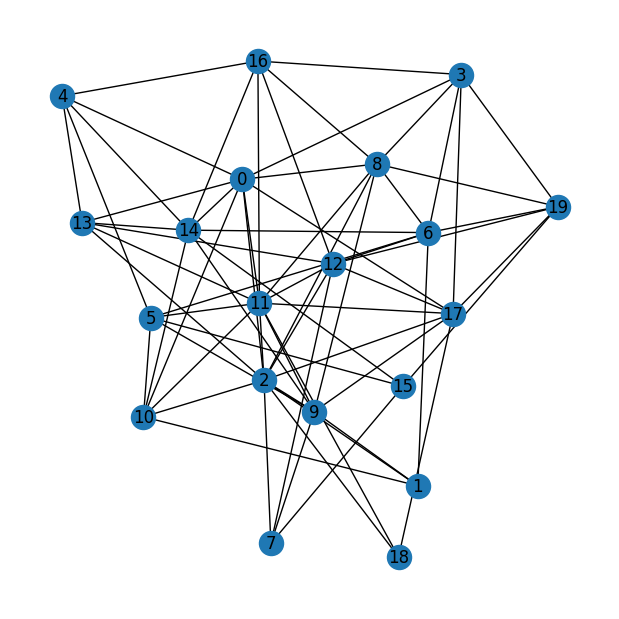

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
N = 20
P = 0.3
seed = 42
G = nx.erdos_renyi_graph(N, P, seed = seed)
plt.figure(figsize = (6, 6))
pos = nx.spring_layout(G, seed = seed)
nx.draw(G, pos, with_labels = True)

Nodes:  20  Edges:  67 Avg Degree:  6.7 Diameter:  3


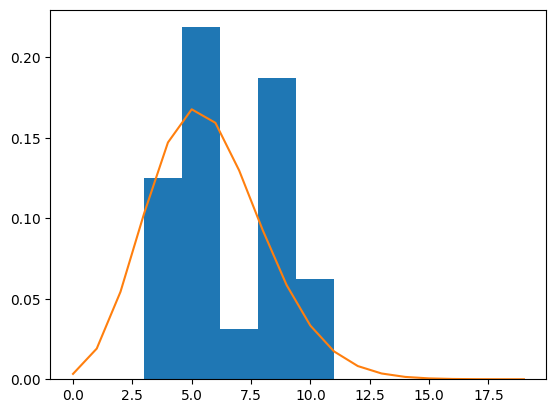

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
print("Nodes: ",num_nodes," Edges: ",num_edges,"Avg Degree: ",avg_degree, 'Diameter: ', nx.diameter(G))
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins = round(np.sqrt(N)) + 1, density = True)
from scipy.stats import poisson
dist = poisson((N-1)*P)
l = np.array(range(N))
plt.plot(l, dist.pmf(l))

In [ ]:
nx.center(G)

[0, 2, 5, 8, 9, 11, 12, 13, 17]

## Модель Барбаши-Альберт (предпочтительного соединения)

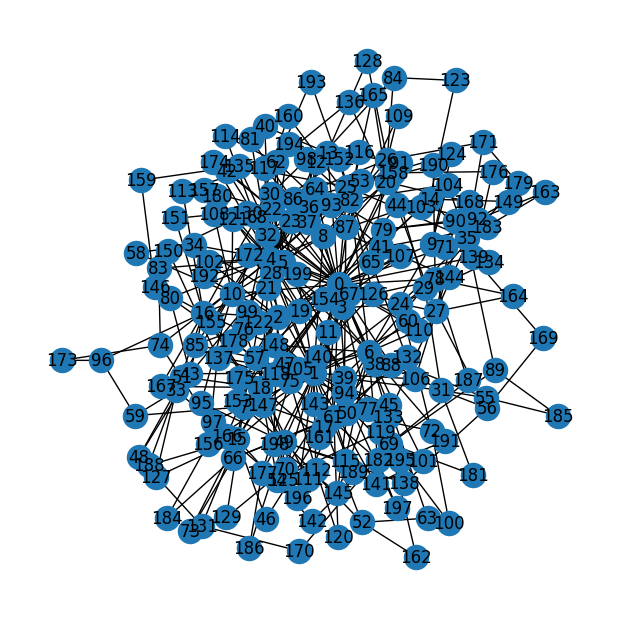

In [ ]:
m0 = 2
N = 200
seed = 42
G = nx.barabasi_albert_graph(N, m0, seed = seed)
plt.figure(figsize=(6,6))
pos = nx.spring_layout(G, seed = seed)
nx.draw(G, pos, with_labels = True)

In [ ]:
nx.diameter(G)

6

Nodes:  200  Edges:  396 Avg Degree:  3.96 Diameter:  6


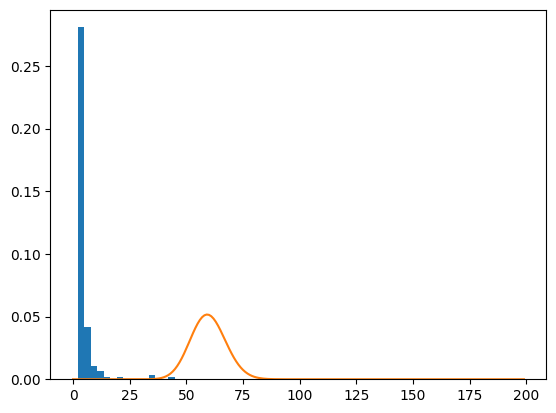

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
print("Nodes: ",num_nodes," Edges: ",num_edges,"Avg Degree: ",avg_degree, 'Diameter: ', nx.diameter(G))
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins = round(np.sqrt(N)) + 1, density = True)
from scipy.stats import poisson
dist = poisson((N-1)*P)
l = np.array(range(N))
plt.plot(l, dist.pmf(l))

Nodes:  200  Edges:  396 Avg Degree:  3.96 Diameter:  6


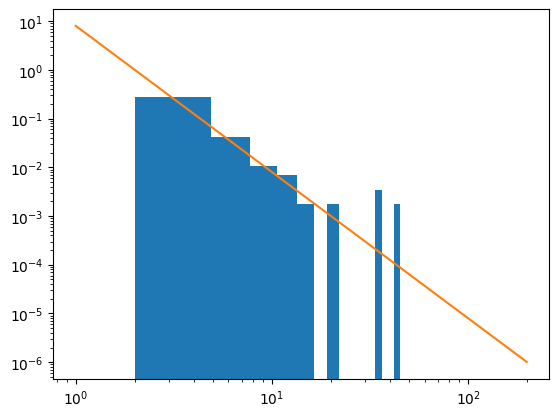

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
print("Nodes: ",num_nodes," Edges: ",num_edges,"Avg Degree: ",avg_degree, 'Diameter: ', nx.diameter(G))
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins = round(np.sqrt(N)) + 1, density = True)
from scipy.stats import poisson
l = np.array(range(1,N)).astype(float)
plt.plot(l, 2*(m0**2)*(l**(-3)))
plt.xscale('log')
plt.yscale('log')

## Модель Уоттса-Строгаца (тесного мира)

Типичное расстояние между двумя нодами растёт процпорционально логорифму от числа вершин

$L = log(N)$

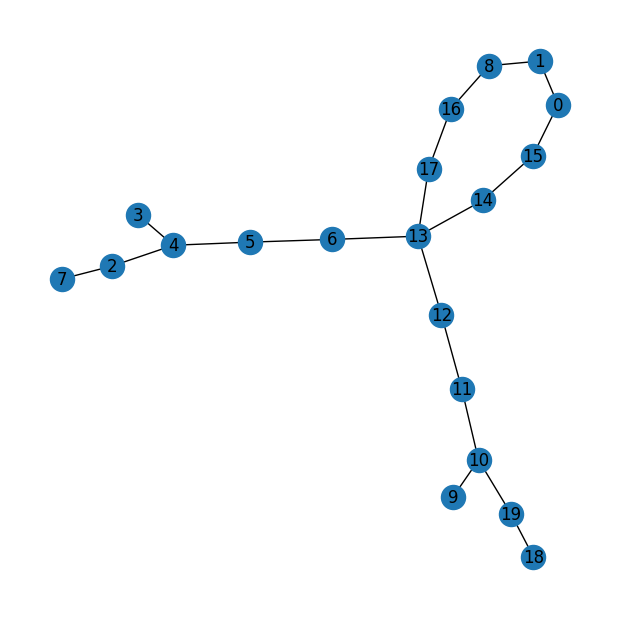

In [ ]:
N = 20
seed = 42
G = nx.watts_strogatz_graph(N, m0, P, seed = seed)
plt.figure(figsize=(6,6))
pos = nx.spring_layout(G, seed = seed)
nx.draw(G, pos, with_labels = True)

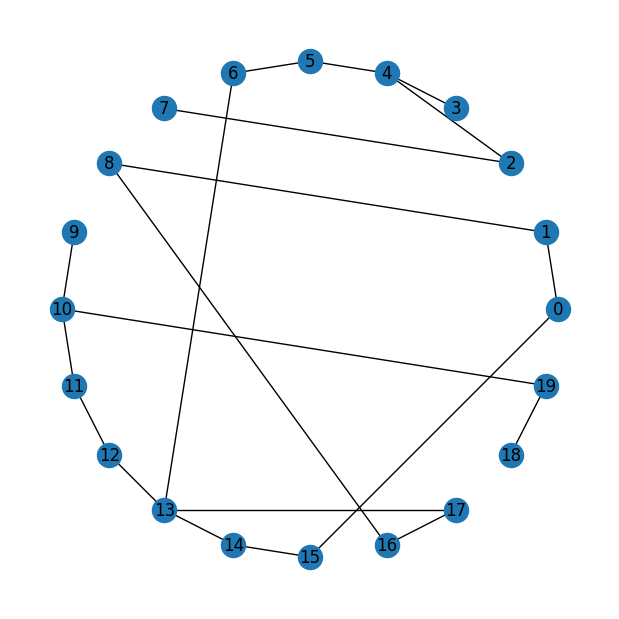

In [ ]:
plt.figure(figsize=(6,6))
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels = True)

Кавайный Камада

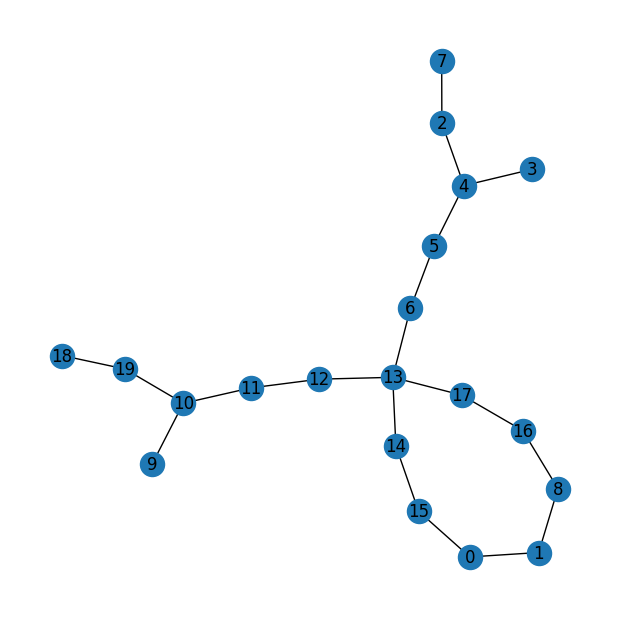

In [ ]:
plt.figure(figsize=(6,6))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels = True)

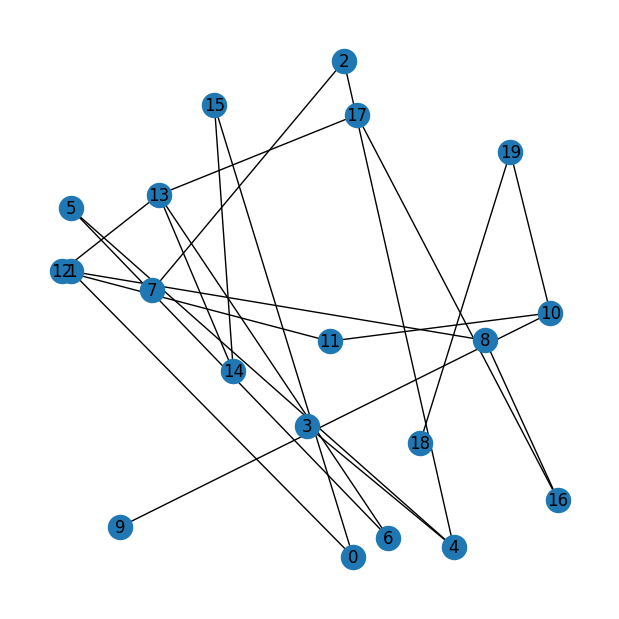

In [ ]:
plt.figure(figsize=(6,6))
pos = nx.random_layout(G, seed = 510)
nx.draw(G, pos, with_labels = True)

Локальный коэффициент кластеризации - насколько соседи для вершины являются соседями между собой

Транзитивность - процент треугольников в сети

In [ ]:
nx.transitivity(G), nx.average_clustering(G)

(0, 0.0)

# Некоторые реальные графы

In [ ]:
!wget -c http://www-personal.umich.edu/~mejn/netdata/football.zip
!unzip football.zip

--2025-09-12 02:05:20--  http://www-personal.umich.edu/~mejn/netdata/football.zip
Resolving www-personal.umich.edu (www-personal.umich.edu)... 141.211.243.103
Connecting to www-personal.umich.edu (www-personal.umich.edu)|141.211.243.103|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://public.websites.umich.edu/~mejn/netdata/football.zip [following]
--2025-09-12 02:05:21--  https://public.websites.umich.edu/~mejn/netdata/football.zip
Resolving public.websites.umich.edu (public.websites.umich.edu)... 141.211.243.103
Connecting to public.websites.umich.edu (public.websites.umich.edu)|141.211.243.103|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4409 (4.3K) [application/zip]
Saving to: ‘football.zip’

football.zip        100%[===================>]   4.31K  --.-KB/s    in 0s      

2025-09-12 02:05:21 (730 MB/s) - ‘football.zip’ saved [4409/4409]

Archive:  football.zip
  inflating: football.gml            
  inflating: footba

In [ ]:
!head -n 20 football.gml

Creator "Mark Newman on Sat Jul 22 05:32:16 2006"
graph
[
  directed 0
  node
  [
    id 0
    label "BrighamYoung"
    value 7
  ]
  node
  [
    id 1
    label "FloridaState"
    value 0
  ]
  node
  [
    id 2
    label "Iowa"


{7, 8, 9, 10, 11, 12}


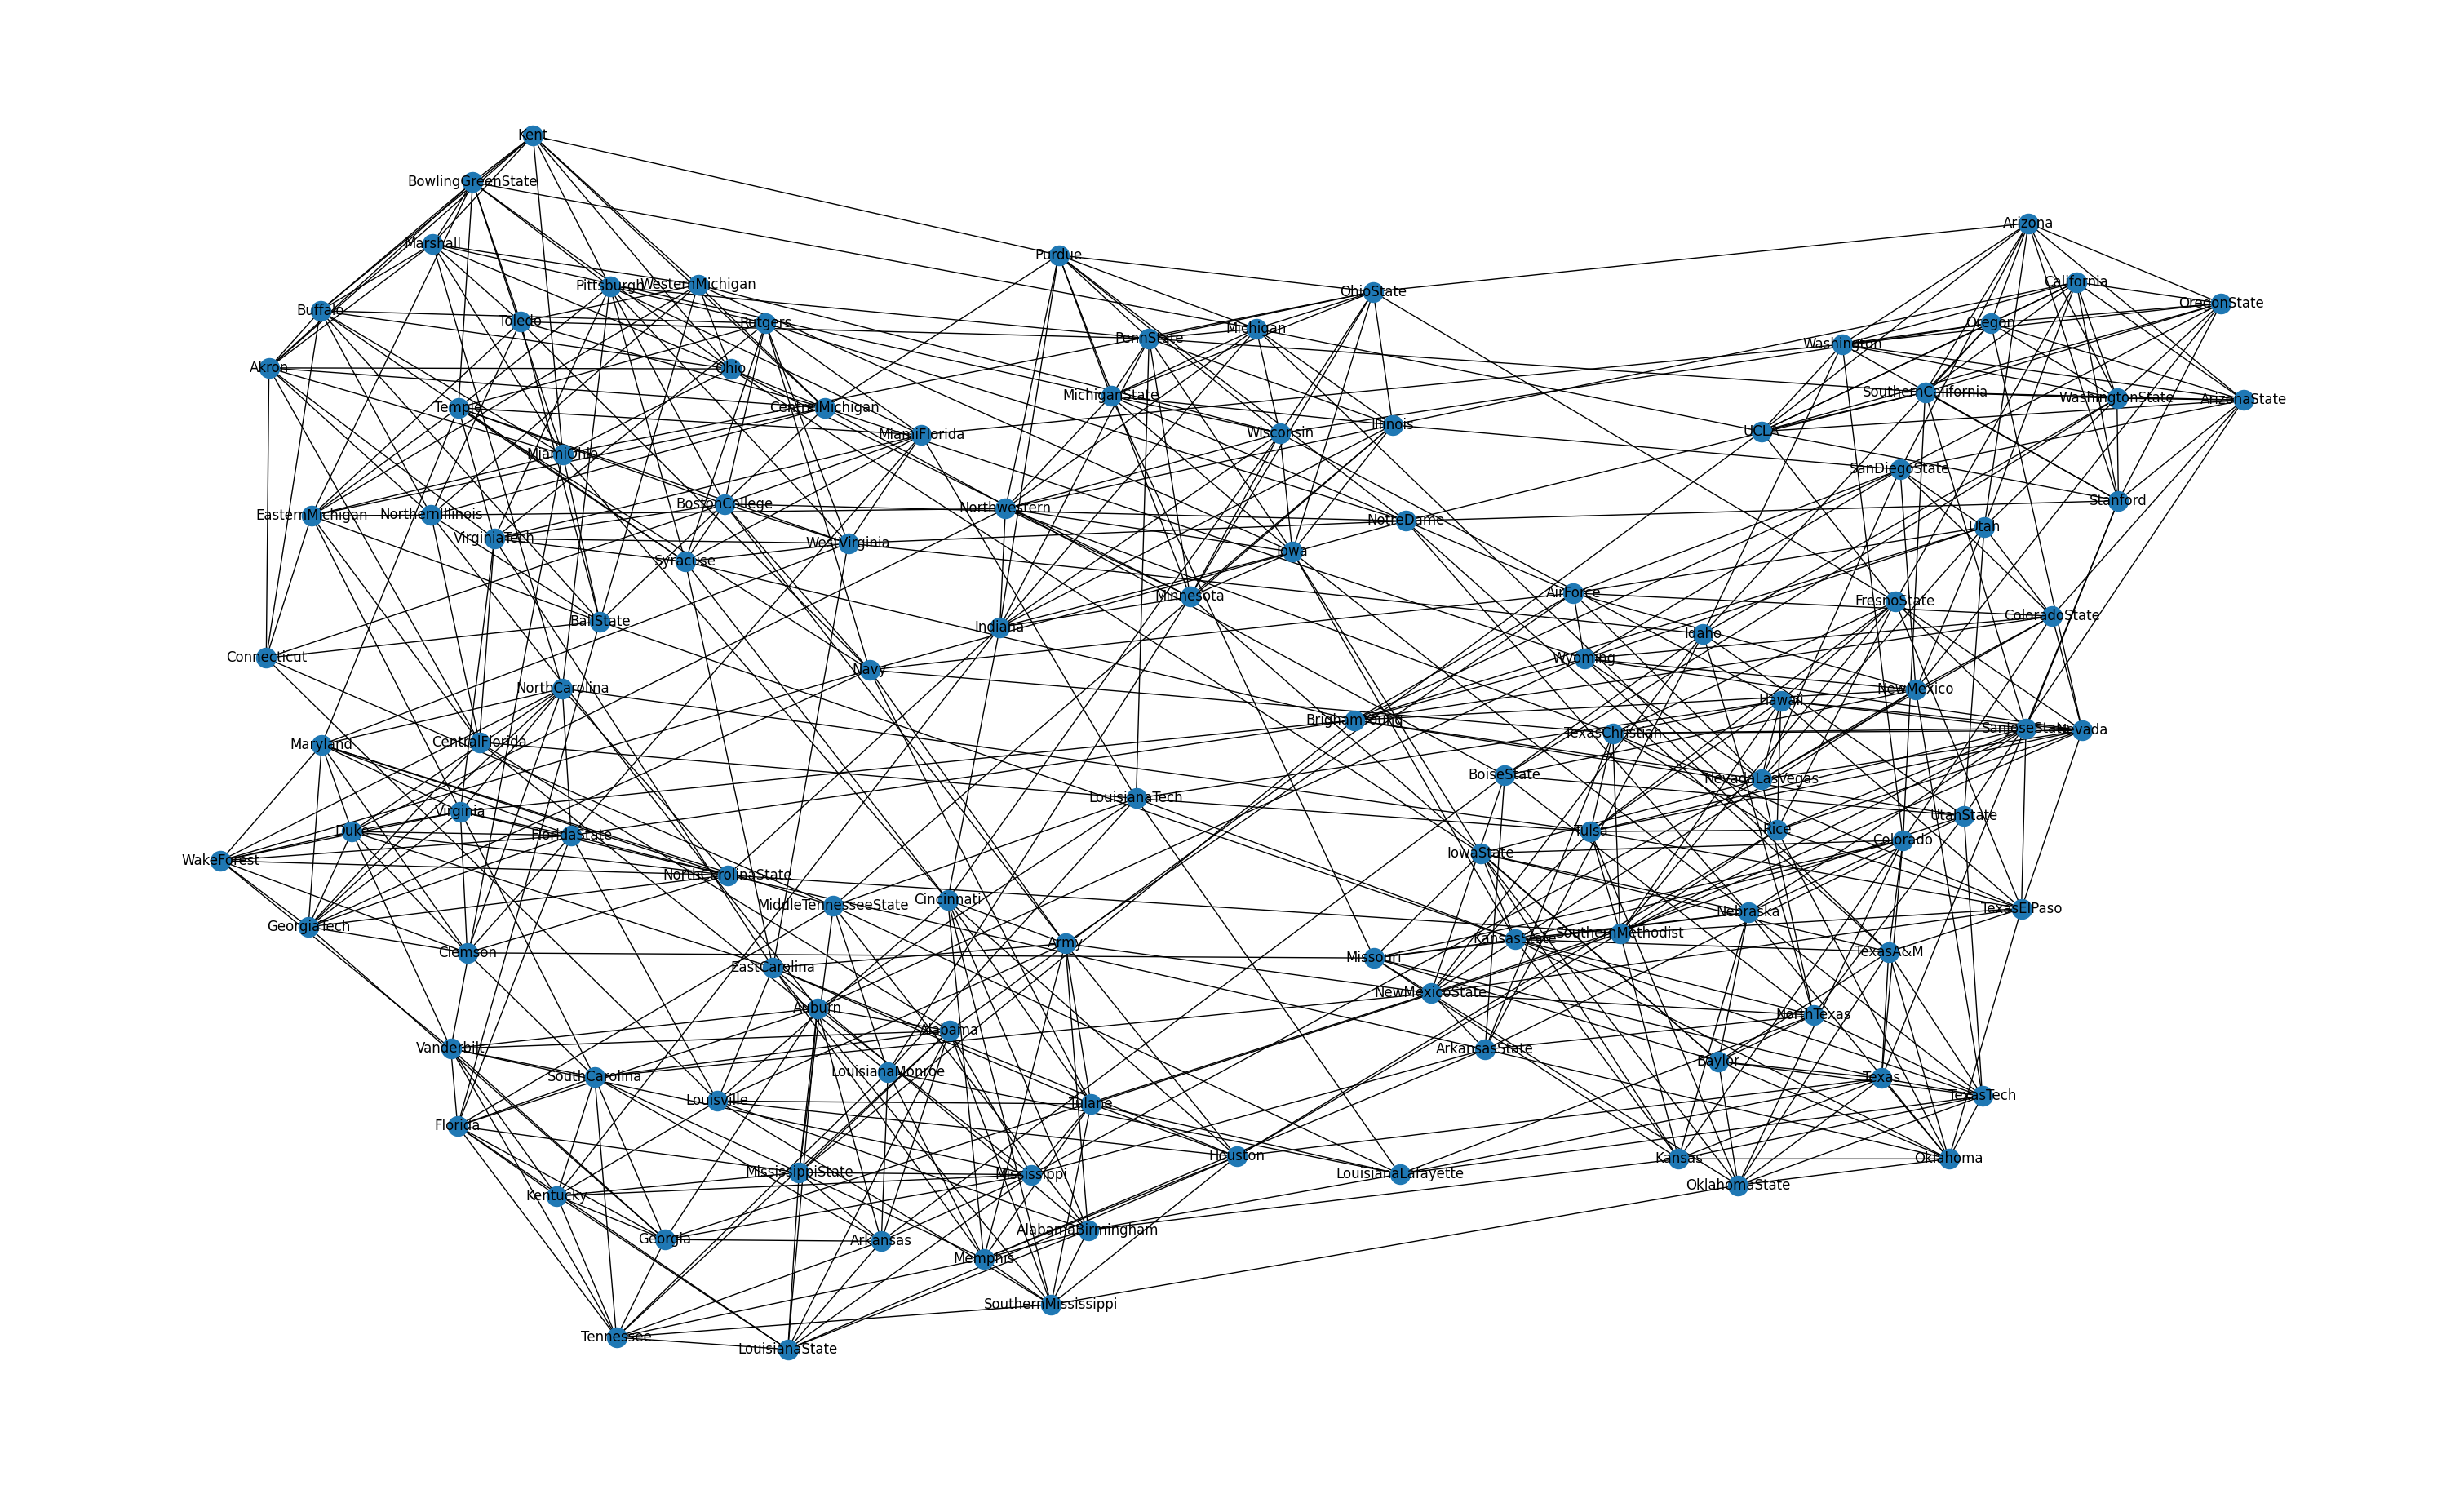

In [ ]:
import matplotlib as mpl
import networkx as nx
import matplotlib.pyplot as plt
txt = open('football.txt').readlines()
gml = open('football.gml').readlines()[1:]
G = nx.parse_gml(gml)
d = dict(G.degree)
print(set(d.values()))
low, *_, high = sorted(d.values())
norm = mpl.colors.Normalize(vmin=low, vmax=high, clip=True)
mapper = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.twilight_shifted)
options = {'node_size':50, 'linewidths':0, 'width':0.1,}
plt.figure(figsize=(30,18))
nx.draw(G,with_labels = True)

# Центральности

In [ ]:
import pandas as pd
def createBarChartForCentralityMeasures(sorted_centrality_teams, centrality_name):
    df = pd.DataFrame(sorted_centrality_teams, columns=['Team', centrality_name])
    return df

metric_main_df = pd.DataFrame(index=list(d.keys()))

degree_centrality_df = createBarChartForCentralityMeasures(sorted(nx.degree_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Degree Centrality')
closeness_centrality_df = createBarChartForCentralityMeasures(sorted(nx.closeness_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Closeness Centrality')
betweenness_centrality_df = createBarChartForCentralityMeasures(sorted(nx.betweenness_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Betweenness Centrality')
eigenvector_centrality_df = createBarChartForCentralityMeasures(sorted(nx.eigenvector_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Eigenvector Centrality')
pagerank_df = createBarChartForCentralityMeasures(sorted(nx.pagerank(G).items(), key=lambda x:x[1], reverse=True), 'PageRank')
hub, auth = nx.hits(G)
hubs_df = createBarChartForCentralityMeasures(sorted(hub.items(), key=lambda x:x[1], reverse=True), 'Hubs')
authorities_df = createBarChartForCentralityMeasures(sorted(auth.items(), key=lambda x:x[1], reverse=True), 'Authorities')

for metric in [degree_centrality_df, closeness_centrality_df, betweenness_centrality_df, eigenvector_centrality_df, pagerank_df, hubs_df, authorities_df]:
    metric = metric.set_index('Team')
    metric_main_df = metric_main_df.join(metric)

metric_main_df

,Degree Centrality,Closeness Centrality,Betweenness Centrality,Eigenvector Centrality,PageRank,Hubs,Authorities
BrighamYoung,0.105263,0.423792,0.032490,0.106503,0.009588,0.010092,0.010092
FloridaState,0.105263,0.413043,0.017621,0.096385,0.009641,0.009132,0.009132
Iowa,0.105263,0.407143,0.013122,0.116262,0.009509,0.011017,0.011017
KansasState,0.105263,0.420664,0.023070,0.106250,0.009617,0.010069,0.010069
NewMexico,0.096491,0.402827,0.010664,0.101190,0.008887,0.009589,0.009589
...,...,...,...,...,...,...,...
TexasChristian,0.096491,0.413043,0.014370,0.114943,0.008777,0.010893,0.010893
California,0.096491,0.382550,0.007516,0.111198,0.008809,0.010538,0.010538
AlabamaBirmingham,0.087719,0.395833,0.011582,0.073015,0.008369,0.006918,0.006918
Arkansas,0.087719,0.377483,0.006498,0.070452,0.008369,0.006675,0.006675


# Графлеты

\- элементарные графы



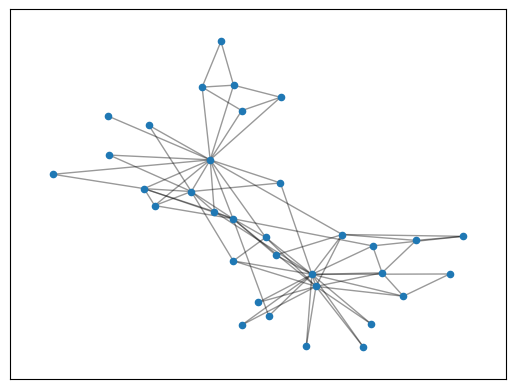

In [ ]:
seed = 42
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=seed)
fig, ax = plt.subplots()
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=20)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4)
plt.show()

Nodes:  34  Edges:  78 Avg Degree:  4.588235294117647 Diameter:  5


(array([0.22058824, 0.04595588, 0.01838235, 0.00919118, 0.01838235]),
 array([ 1. ,  4.2,  7.4, 10.6, 13.8, 17. ]),
 <BarContainer object of 5 artists>)

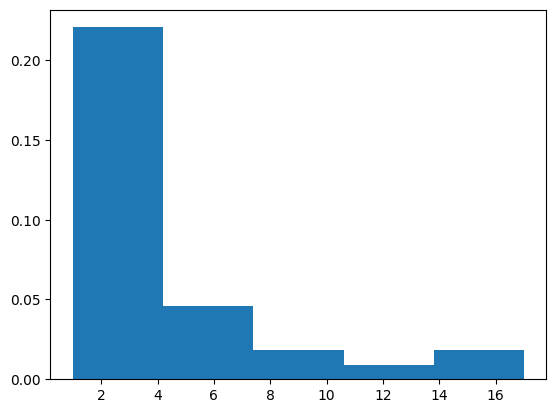

In [ ]:
N = 20
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
print("Nodes: ",num_nodes," Edges: ",num_edges,"Avg Degree: ",avg_degree, 'Diameter: ', nx.diameter(G))
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins = round(np.sqrt(N)) + 1, density = True)

In [ ]:
k = G.degree()
cc = nx.closeness_centrality(G)
bc = nx.betweenness_centrality(G)
ec = nx.eigenvector_centrality(G)
kcl = nx.clustering(G)
x = []
for i,v in kcl.items():
  x.append([v, k[i], cc[i], bc[i], ec[i]])
x = np.array(x)

Небольшое задание по созданию многомерного вектора признаков и его отображения после понижения размерности

In [ ]:
from umap.umap_ import UMAP
ump = UMAP()
umap_d = ump.fit_transform(x[:,:])

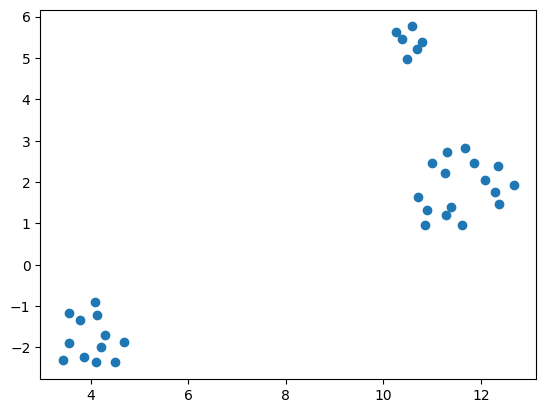

In [ ]:
plt.scatter(umap_d[:,0],umap_d[:,1]);

Содержание графлетов в графе

In [ ]:
import pyfglt.fglt as fg
F = fg.compute(G)
F.head()

,[0] vertex (==1),[1] degree,[2] 2-path,[3] bifork,[4] 3-cycle,"[5] 3-path, end","[6] 3-path, interior","[7] claw, leaf","[8] claw, root","[9] paw, handle","[10] paw, base","[11] paw, center",[12] 4-cycle,"[13] diamond, off-cord","[14] diamond, on-cord",[15] 4-clique
Node id (0-based),,,,,,,,,,,,,,,,
0,1,16,17,102,18,81,197,13,352,6,34,171,10,2,30,7
1,1,9,19,24,12,73,56,33,32,8,80,27,6,2,18,7
2,1,10,34,34,11,72,179,84,54,17,75,51,20,6,8,7
3,1,6,20,5,10,49,11,56,1,5,81,5,0,4,7,7
4,1,3,16,1,2,17,1,64,0,15,25,0,1,2,1,0


In [ ]:
F = np.array(F)

In [ ]:
from umap.umap_ import UMAP
ump = UMAP(n_components=2)
umap_d = ump.fit_transform(F[:,:])
from sklearn.mixture import GaussianMixture
clf = GaussianMixture(n_components = 2)
c = clf.fit_predict(umap_d)

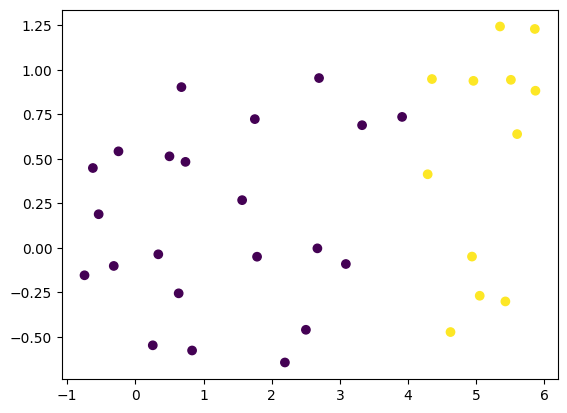

In [ ]:
plt.scatter(umap_d[:,0],umap_d[:,1],c=c);

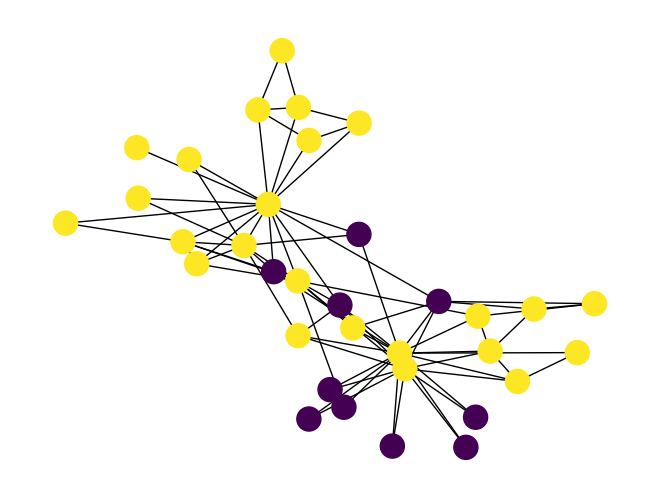

In [ ]:
nx.draw(G, pos, node_color=c)

(34, 2)


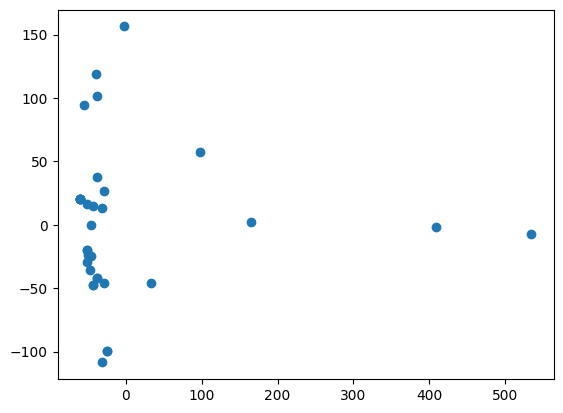

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X=pca.fit_transform(F)
print(X.shape)
plt.scatter(X[:,0],X[:,1])

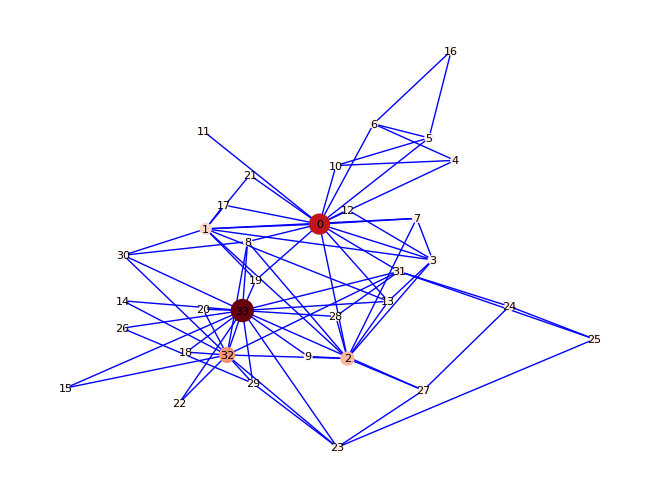

In [ ]:
nx.draw(G, pos,
            node_color=X[:,0],
            cmap=plt.cm.Reds,
            node_size=[50 + (200*v)/X[:,0].max() for v in list(X[:,0])],
            with_labels=True,
            font_size=8,
            edge_color='blue')

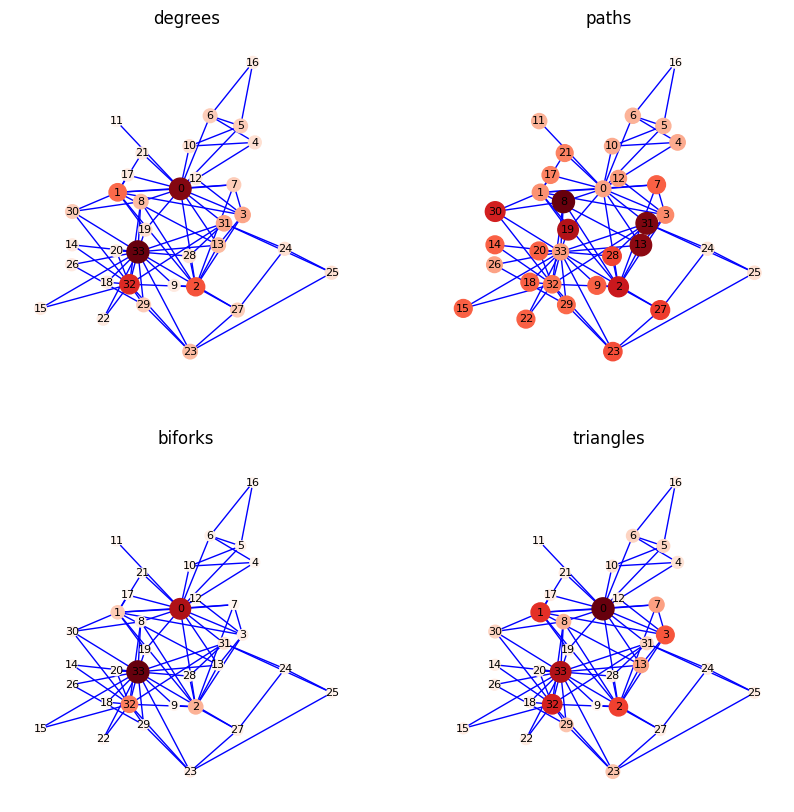

In [ ]:
pos = nx.kamada_kawai_layout(G)
# norm_vectors = normalize_vectors(graphlet_vectors)

degrees = [F[node,1] for node in G.nodes()]
paths = [F[node,2] for node in G.nodes()]
biforks = [F[node,3] for node in G.nodes()]
triangles = [F[node,4] for node in G.nodes()]
labels=['degrees','paths','biforks','triangles']
# Create subplots
plt.figure(figsize=(10,10))
for i,glt in enumerate((degrees,paths,biforks,triangles)):
 plt.subplot(2, 2, i+1)
 plt.title(labels[i])
 nx.draw(G, pos,
            node_color=glt,
            cmap=plt.cm.Reds,
            node_size=[50 + (200*v)/np.array(glt).max() for v in glt],
            with_labels=True,
            font_size=8,
            edge_color='blue')

Объединение признаков и графлетов

In [ ]:
from umap.umap_ import UMAP
ump = UMAP(n_components=2)
umap_d = ump.fit_transform(np.concatenate((x, F), axis=-1)[:,:])
from sklearn.mixture import GaussianMixture
clf = GaussianMixture(n_components = 2)
c = clf.fit_predict(umap_d)

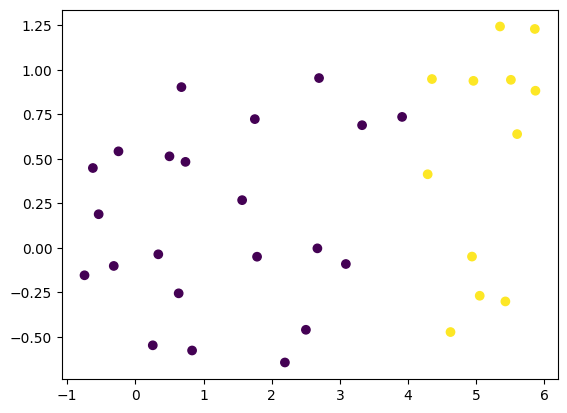

In [ ]:
plt.scatter(umap_d[:,0],umap_d[:,1],c=c);

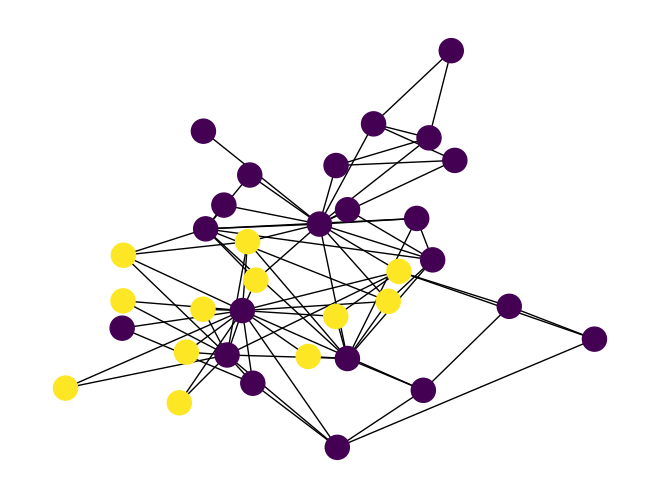

In [ ]:
nx.draw(G, pos, node_color=c)

Кодировка рёбер через графлеты их вершин

In [ ]:
G = nx.karate_club_graph()
pos = nx.kamada_kawai_layout(G)
F = fg.compute(G)
F = np.array(F)
edge_f = []
for u,v in G.edges:
  edge_f.append(F[u]+F[v])
edge_f = np.array(edge_f)

PCA + DBSCAN

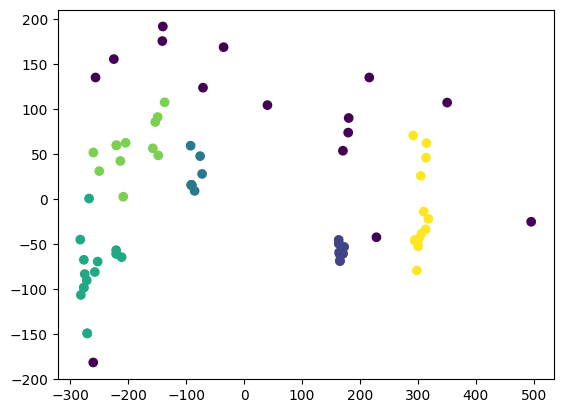

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X=pca.fit_transform(edge_f)
from sklearn.cluster import DBSCAN
clf=DBSCAN(eps=50)
c=clf.fit_predict(X)
plt.scatter(X[:,0],X[:,1],c=c)

/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


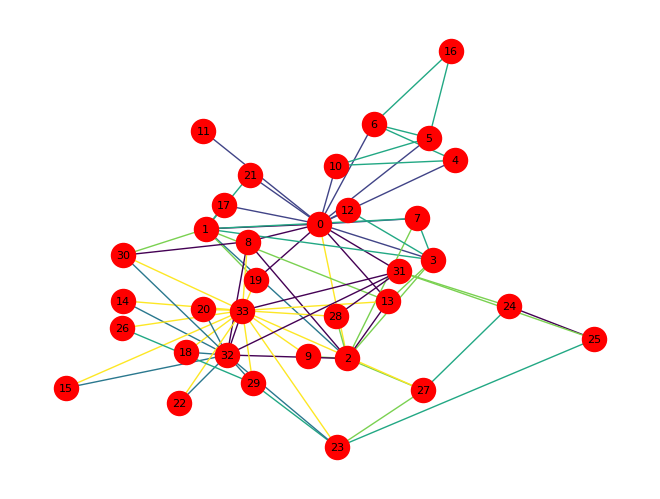

In [ ]:
nx.draw(G, pos,
            node_color='red',
            cmap=plt.cm.Reds,
            with_labels=True,
            font_size=8,
            edge_color=c)

Umap + GaussianMixture

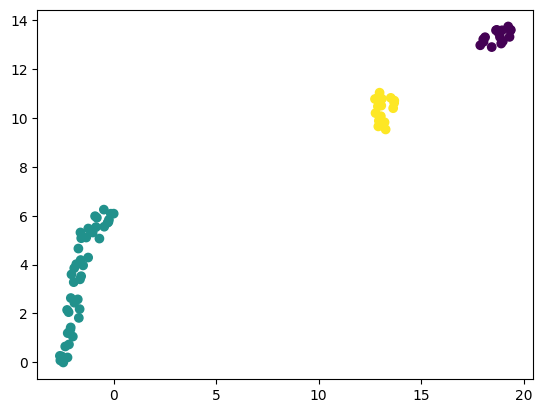

In [ ]:
from umap.umap_ import UMAP
ump = UMAP(n_components=2)
umap_d = ump.fit_transform(edge_f[:,:])
from sklearn.mixture import GaussianMixture
clf = GaussianMixture(n_components = 3)
c = clf.fit_predict(umap_d)
plt.scatter(umap_d[:,0],umap_d[:,1], c=c)

/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


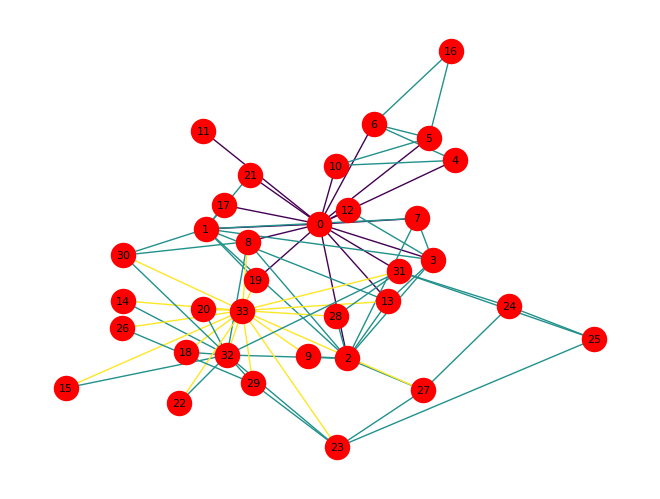

In [ ]:
nx.draw(G, pos,
            node_color='red',
            cmap=plt.cm.Reds,
            with_labels=True,
            font_size=8,
            edge_color=c)

Гистограмма кратчайших путей

(array([ 34.,   0., 156.,   0., 530.,   0., 274.,   0., 146.,  16.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

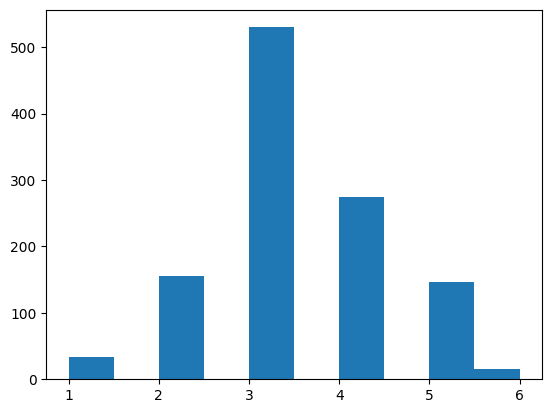

In [ ]:
edge_f = {}
ls = []
for u in G.nodes:
 for v in G.nodes:
  l=len(nx.shortest_path(G,u,v))
  ls.append(l)
plt.hist(ls)

(array([458.,  30.,  48.,  64.,  86.,  66.,  70.,  12.,  64.,  32.,   4.,
         62.,   8.,  42.,   4.,   0.,   0.,  36.,   0.,   0.,   2.,   0.,
          6.,   0.,   0.,   4.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,
         56.]),
 array([0.        , 0.02941176, 0.05882353, 0.08823529, 0.11764706,
        0.14705882, 0.17647059, 0.20588235, 0.23529412, 0.26470588,
        0.29411765, 0.32352941, 0.35294118, 0.38235294, 0.41176471,
        0.44117647, 0.47058824, 0.5       , 0.52941176, 0.55882353,
        0.58823529, 0.61764706, 0.64705882, 0.67647059, 0.70588235,
        0.73529412, 0.76470588, 0.79411765, 0.82352941, 0.85294118,
        0.88235294, 0.91176471, 0.94117647, 0.97058824, 1.        ]),
 <BarContainer object of 34 artists>)

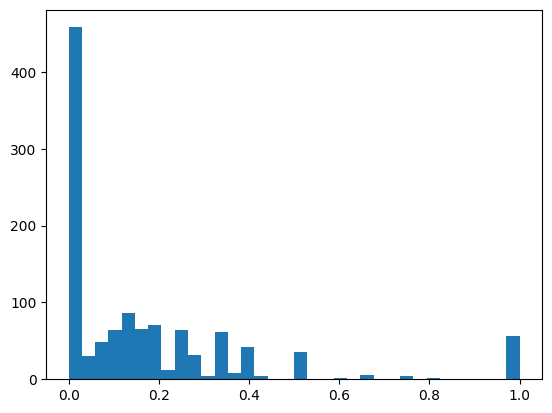

In [ ]:
edge_f = {}
ls = []
for u in G.nodes:
 for v in G.nodes:
  pred = nx.jaccard_coefficient(G, [(u,v)])
  l = list(pred)[0][2]
  ls.append(l)
plt.hist(ls, bins = round(len(ls)**0.5))

In [ ]:
from sklearn.mixture import GaussianMixture
clf = GaussianMixture(n_components = 3)
c1 = np.array(c)
gmc = clf.fit_predict(c1[:,np.newaxis])
plt.figure(figsize=(10,10))
# ...

# Перекрытие глобальных окресностей

Индекс Катца

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

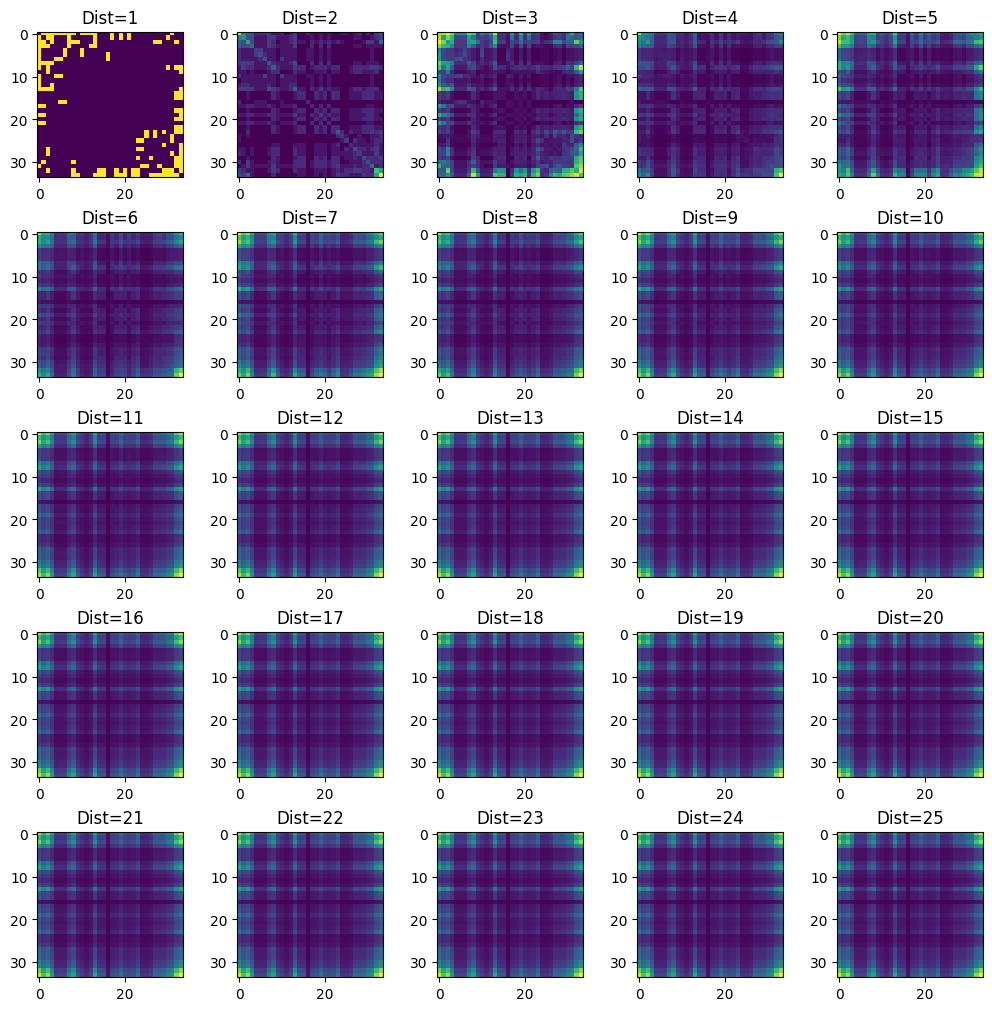

In [ ]:
AG = nx.adjacency_matrix(G).toarray()
AG[AG>0] = 1
AGI = np.diag(np.ones(AG.shape[0]))
plt.figure(figsize=(10,10), constrained_layout=True)
for i in range(25):
  AGI=AGI@AG
  plt.subplot(5,5,i+1)
  plt.imshow(AGI)
  plt.title(f'Dist={(i+1)}')

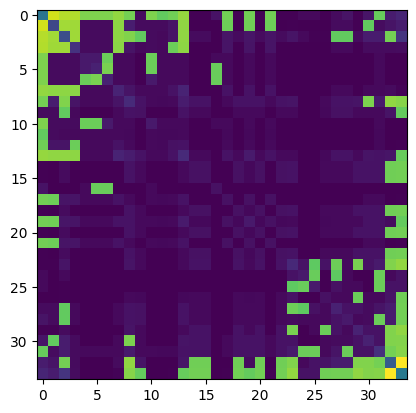

In [ ]:
beta = 1/AG.shape[0]
l = np.diag(np.ones(AG.shape[0]))
result = np.linalg.inv(l-(beta*AG))-l
plt.imshow(result)

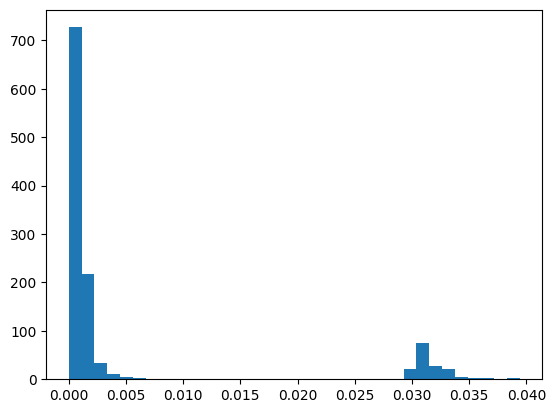

In [ ]:
plt.hist(result.reshape(-1,1),bins=35);

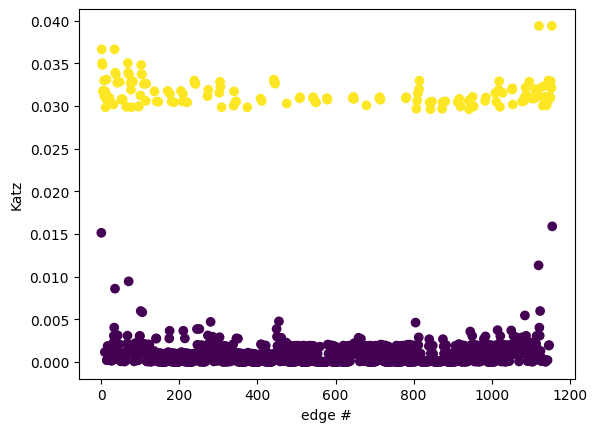

In [ ]:
t1=np.zeros(result.shape[0]*result.shape[1])
f=result.reshape(-1,1)[:,0]
t1[f>0.025]=1
t1[f<=0.025]=0
plt.scatter(range(result.shape[0]*result.shape[0]), result.reshape(-1,1),c=t1)
plt.xlabel('edge #')
plt.ylabel('Katz')
t=t1.reshape(result.shape[0],result.shape[1])

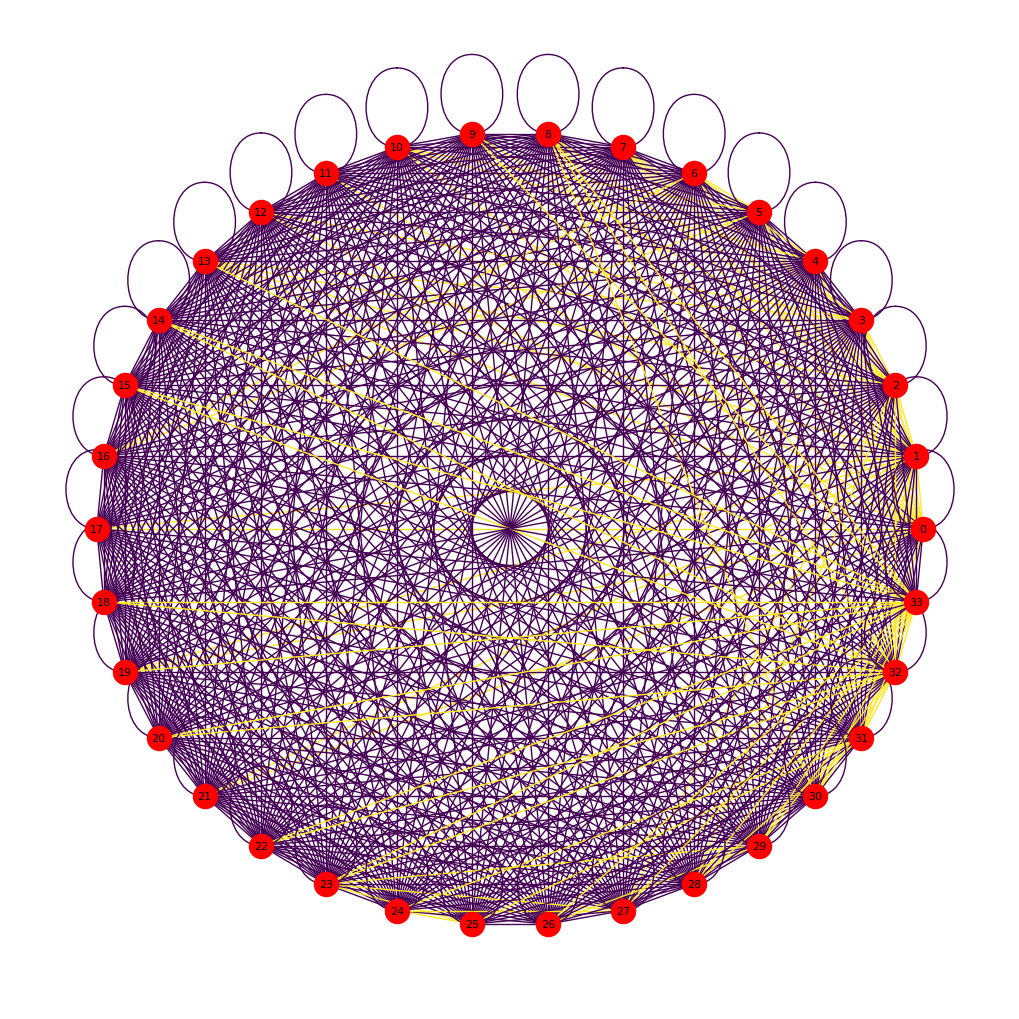

In [ ]:
edge_f = {}
G1=nx.Graph()
for u in G.nodes:
 for v in G.nodes:
  l=t[u,v]
  edge_f[tuple((u,v))]=l
  G1.add_edge(u,v,weight=l)
pos=nx.circular_layout(G1)
edge_labels = nx.get_edge_attributes(G1, 'weight')
c = []
for u,v in G1.edges:
  c.append(edge_labels[u,v])
plt.figure(figsize=(10,10))
nx.draw(G1, pos, node_color='red',
        cmap=plt.cm.Reds,
        with_labels=True,
        font_size=8,
        edge_color=c)

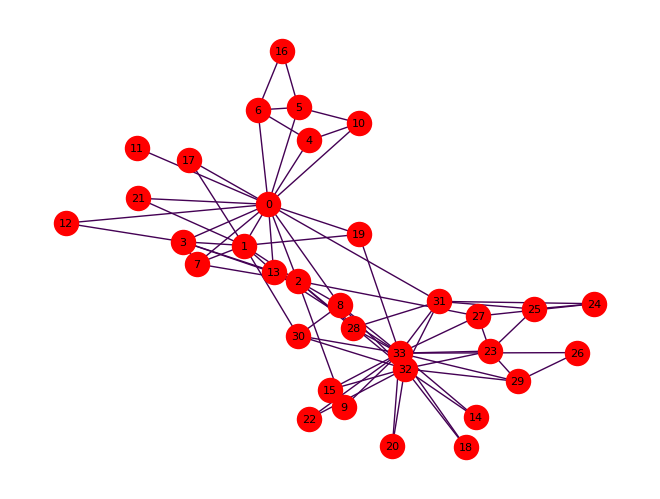

In [ ]:
c = []
for u,v in G.edges:
  c.append(edge_labels[u,v])
seed = 42
pos = nx.spring_layout(G, seed = seed)
nx.draw(G, pos, node_color='red',
      cmap=plt.cm.Reds,
      with_labels=True,
      font_size=8,
      edge_color=c)

# Графовые ядра

Способы:
- графлетное ядро (стоит нормировать по сумме)
- ядро Вайсфалера-Лемана
 - Алгоритм:
   - каждая вершина размечается
   - через запятую к названию добавляется степень вершины
   - для каждого представления создаётся хеш -> снова всё переименовывается
   - к названию теперь записываются хеши соседей -> всё повторяется
   - алгоритм заканчивается, когда шаг достигает диаметра графа

In [ ]:
import networkx as nx
import numpy as np

def get_hashes(list_labels,hashes=[]):
 idt={}
 for labels in list_labels:
  for k in list(labels.keys()):
   if not (labels[k] in idt):
    idt[labels[k]]=1
 hashes=[k for k in idt.keys()]
 return hashes

def weisfeiler_lehman(G, max_iter=50):
    labels = {n: hash(tuple([0])) for n in G.nodes()}
    for itt in range(max_iter):
        new_labels = {
            n: hash (tuple([labels[n]]+sorted(labels[v] for v in G[n])))
            for n in G}
        hashes=get_hashes([new_labels])
        idt={v:k for k,v in enumerate(hashes)}
        new_labels_emb = {n: idt[new_labels[n]] for n in G}
        new_labels=new_labels_emb
        if new_labels == labels: break
        labels = new_labels
    return labels

In [ ]:
def emb(labels,hashes):
  l = len(hashes)
  idt = {v:k for k,v in enumerate(hashes)}
  vl_emb = np.zeros(l).astype(int)
  for k in list(labels.keys()):
    if labels[k] in hashes:
      vl_emb[idt[labels[k]]]+=1
  return vl_emb

In [ ]:
G1 = nx.karate_club_graph()
labels1 = weisfeiler_lehman(G1, max_iter=100)
G2 = nx.cycle_graph(32)
labels2 = weisfeiler_lehman(G2, max_iter=100)
G3 = nx.cycle_graph(35)
labels3 = weisfeiler_lehman(G3, max_iter=100)
G4 = nx.cycle_graph(5)
labels4 = weisfeiler_lehman(G4, max_iter=100)
hashes = get_hashes([labels1,labels2,labels3,labels4])
print(emb(labels1,hashes))
print(emb(labels2,hashes))
print(emb(labels3,hashes))
print(emb(labels4,hashes))
l1=np.abs(emb(labels4,hashes)).sum()
print(emb(labels4,hashes)/l1)

[1 1 1 1 2 2 1 1 1 1 1 1 5 1 2 1 1 1 1 1 1 1 1 1 1 1 1]
[32  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0]
[35  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0]
[5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]


# Случайные блуждания

In [ ]:
import random

def drawGraphWithWalk(G,walk):
 pos=nx.kamada_kawai_layout(G)
 c,k=[],0
 for u,v in G.edges:
  found=False
  for k in range(len(walk)-1):
   if (walk[k]==u and walk[k+1]==v) or (walk[k]==v and walk[k+1]==u):
    found=True
    break
  if found: c.append('red')
  else: c.append('blue')
 nx.draw(G,pos,with_labels=True,edge_color=c)
 print(walk)

In [ ]:
G = nx.karate_club_graph()

def generate_random_walks(G, num_walks=10, walk_length=80, start_point=None):
  walks = []
  nodes = list(G.nodes())
  for _ in range(num_walks):
    if start_point:
      node = nodes[start_point]
    else:
      random.shuffle(nodes)
      node = nodes[0]
    walk = [node]
    for _ in range(walk_length-1):
      curr = walk[-1]
      neighbors = list(G.neighbors(curr))
      if neighbors: walk.append(random.choice(neighbors))
      else: walk.append(curr)
    walks.append(walk)
  return walks

[25, 31, 33, 29, 23, 29, 23]


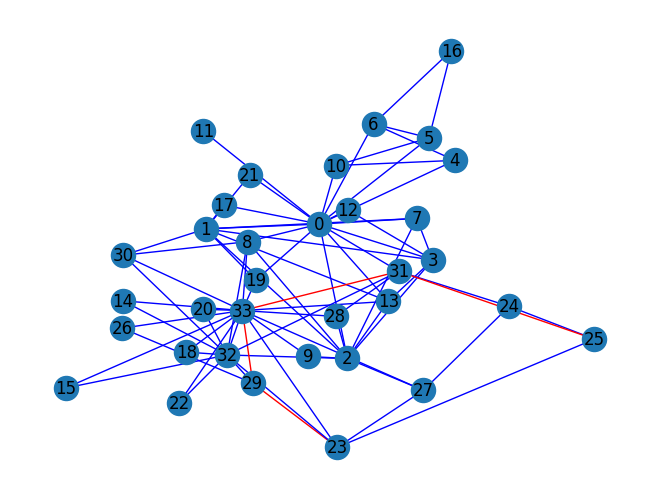

In [ ]:
walks = generate_random_walks(G, num_walks=1, walk_length=7)
drawGraphWithWalk(G,walks[0])

In [ ]:
walks = generate_random_walks(G, num_walks=100000, walk_length=3, start_point=30)
s = 0
for walk in walks:
  if 17 in walk: s+=1
s / len(walks)

0.02677

In [ ]:
import torch
from torch import nn
import torch.optim as optim

class GraphEmbedder(nn.Module):
    def __init__(self, num_nodes, embedding_dim):
        super(GraphEmbedder, self).__init__()
        self.embeddings = nn.Embedding(num_nodes, embedding_dim)
    def forward(self, node_ids):
        return self.embeddings(node_ids)

def contrastive_loss(pos_scores, neg_scores):
    loss=0
    if len(pos_scores) > 0: loss += -torch.log(torch.sigmoid(pos_scores) + 1e-15).sum()
    if len(neg_scores) > 0: loss += torch.log(torch.sigmoid(neg_scores) + 1e-15).sum()
    return loss

def generate_training_pairs(nodes, walks, window_size=1, num_neg_samples=5):
    vocab_size, pairs = len(nodes), []
    for walk in walks:
        for i, center in enumerate(walk):
            start = max(0, i - window_size)
            end = min(len(walk), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    pos_ctx = walk[j]
                    pairs.append((center, pos_ctx, 1))  # Positive pair
                    for _ in range(num_neg_samples):
                        neg_ctx = random.randint(0, vocab_size - 1)
                        while neg_ctx == center or neg_ctx == pos_ctx:
                            neg_ctx = random.randint(0, vocab_size - 1)
                        pairs.append((center, neg_ctx, 0))  # Negative pair
    return window_size+num_neg_samples,pairs
batch,pairs=generate_training_pairs(list(G.nodes()), walks)
print(batch)

6


In [ ]:
num_nodes = G.number_of_nodes()
num_nodes

34

In [ ]:
nodes=list(G.nodes())
batch_size,pairs = generate_training_pairs(nodes, walks)
batch_size

6

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
embedding_dim,lr=3,1e-2
model = GraphEmbedder(num_nodes, embedding_dim).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr)
walks = generate_random_walks(G, num_walks=1000, walk_length=10)
nodes=list(G.nodes())
batch_size,pairs = generate_training_pairs(nodes, walks)
pairs = np.array(pairs) # (N, 3): [center, context, label]
centers = torch.tensor(pairs[:, 0], dtype=torch.long).to(device)
contexts = torch.tensor(pairs[:, 1], dtype=torch.long).to(device)
labels = torch.tensor(pairs[:, 2], dtype=torch.float).to(device)

In [ ]:
model.train()
num_epochs=10
for epoch in range(num_epochs):
    total_loss = 0.0
    for i in range(0, len(pairs), batch_size):
        batch_centers = centers[i:i+batch_size]
        batch_contexts = contexts[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]
        optimizer.zero_grad()
        center_embeds = model(batch_centers)  # (B, d)
        context_embeds = model(batch_contexts)  # (B, d)
        print('c:',center_embeds)
        print('ct:',context_embeds)

        scores = torch.sum(center_embeds * context_embeds, dim=1)  # (B,)
        print('c*ct:',scores)

        pos_scores = scores[batch_labels == 1]
        neg_scores = scores[batch_labels == 0]
        print('pos:',pos_scores)
        print('neg:',neg_scores)
        loss = contrastive_loss(pos_scores,neg_scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{num_epochs}, loss: {total_loss: .4f}')

Выходные данные были обрезаны до нескольких последних строк (5000).
       device='cuda:0', grad_fn=<SumBackward1>)
pos: tensor([-61.2353], device='cuda:0', grad_fn=<IndexBackward0>)
neg: tensor([-54.4002,  54.9305,  62.5860,  58.1085,  62.2137], device='cuda:0',
       grad_fn=<IndexBackward0>)
c: tensor([[-3.8852, -6.4445, -1.7202],
        [-3.8852, -6.4445, -1.7202],
        [-3.8852, -6.4445, -1.7202],
        [-3.8852, -6.4445, -1.7202],
        [-3.8852, -6.4445, -1.7202],
        [-3.8852, -6.4445, -1.7202]], device='cuda:0',
       grad_fn=<EmbeddingBackward0>)
ct: tensor([[ 4.5173,  6.6700,  0.4070],
        [ 4.3986,  5.9645, -1.7150],
        [-3.7587, -5.2937, -3.4084],
        [-3.9956, -5.3282, -1.9934],
        [ 4.1661,  4.9515,  2.3224],
        [-5.0214, -5.2946, -2.3546]], device='cuda:0',
       grad_fn=<EmbeddingBackward0>)
c*ct: tensor([-61.2353, -52.5773,  54.5812,  53.2904, -52.0907,  57.6803],
       device='cuda:0', grad_fn=<SumBackward1>)
pos: tensor([-61.23

KeyboardInterrupt: 

In [ ]:
model.eval()
with torch.no_grad():
  embeddings = model.embeddings.weight.cpu().data.numpy()
embeddings

In [ ]:
from umap.umap_ import UMAP
ump = UMAP()
umap_d = ump.fit_transform(embeddings[:,:])

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
e_opt, s_opt = 1, -1
for e in np.linspace(1,100,100):
  clf=DBSCAN(eps=e)
  c=clf.fit_predict(umap_d)
  if np.unique(c).shape[0]>1:
    s=silhouette_score(umap_d,c)
    if s>s_opt:
      s_opt=s
      e_opt=e
clf=DBSCAN(eps=e_opt)
c=clf.fit_predict(umap_d)
plt.scatter(d[:, 0], d[:, 1], c=c);

#

In [ ]:
import networkx as nx
import numpy as np
G = nx.karate_club_graph()

def next_node(G, previous, current, p, q):
  neighbors = list(G.neighbors(current))
  alphas = []
  for neighbor in neighbors:
    if neighbor == previous: alpha = 1/p
    elif G.has_edge(neighbor, previous): alpha = 1
    else: alpha = 1/q
    alphas.append(alpha)
  probs = [alpha / sum(alphas) for alpha in alphas]
  next = np.random.choice(neighbors, size=1, p=probs)[0]
  return next

def random_walk(G, start, length, p, q):
  walk = [start]
  for i in range(length):
    current = walk[-1]
    previous = walk[-2] if len(walk) > 1 else None
    next = next_node(G, previous, current, p, q)
    walk.append(next)
  return [int(x) for x in walk]

In [ ]:
walks=random_walk(G, 0, 8, p=0.0001, q=0.0001)
walks

[0, 3, 0, 4, 0, 4, 0, 2, 28]

In [ ]:
def drawGraphWithWalk(G,walk):
 pos=nx.kamada_kawai_layout(G)
 c,k=[],0
 for u,v in G.edges:
  found=False
  for k in range(len(walk)-1):
   if (walk[k]==u and walk[k+1]==v) or (walk[k]==v and walk[k+1]==u):
    found=True
    break
  if found: c.append('red')
  else: c.append('blue')

In [ ]:
drawGraphWithWalk(G,walks)

# Следующий блокнот - [graphs_1.ipynb](https://colab.research.google.com/drive/1ggWsMsUgWl5oHInfGw2TM00WrtQQJnJk?usp=sharing)